# 05 · Whole-image versus quadrant timing

Measure whole-image and sequential quadrant processing for the same integer quantization, after verifying that their outputs agree.

**Inputs:** two web photographs, [NASA astronaut](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut) and [coffee by Rachel Michetti](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee). Original files, source URLs, credits, and checksums are in [assets/](assets/). Both photographs are processed at their original dimensions.

**Group:** Nmertgules and Iliya.

The figures and measurements below are saved outputs from an actual execution. Use Restart Kernel and Run All to reproduce them.

## 1. Load and verify the photographs

The repository includes the images. If this notebook is opened alone in Colab, the same files are downloaded from the versioned URLs and checked against SHA-256 hashes.

In [1]:
%matplotlib inline
from pathlib import Path
from urllib.request import urlopen
import hashlib
import json
from time import perf_counter_ns

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")
plt.rcParams.update({
    "figure.dpi": 95, "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "figure.facecolor": "white", "axes.spines.top": False,
    "axes.spines.right": False,
})
SOURCES = [{'name': 'astronaut', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png', 'sha256': '88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5', 'bytes': 791555, 'credit': 'NASA', 'license': 'Public domain', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut'}, {'name': 'coffee', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/coffee.png', 'sha256': 'cc02f8ca188b167c775a7101b5d767d1e71792cf762c33d6fa15a4599b5a8de7', 'bytes': 466706, 'credit': 'Rachel Michetti, courtesy of Pikolo Espresso Bar', 'license': 'CC0 1.0', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee'}]
# Works from the repository root, from week2/, and in a standalone Colab notebook.
asset_dir = next((p for p in (Path("assets"), Path("week2/assets"))
                  if p.is_dir()), Path("assets"))
asset_dir.mkdir(parents=True, exist_ok=True)
images = {}
for source in SOURCES:
    path = asset_dir / (source["name"] + ".png")
    if not path.is_file():
        with urlopen(source["url"], timeout=45) as response:
            path.write_bytes(response.read())
    raw = path.read_bytes()
    assert hashlib.sha256(raw).hexdigest() == source["sha256"], f"Photo checksum mismatch: {path.name}"
    bgr = cv2.imdecode(np.frombuffer(raw, dtype=np.uint8), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Cannot decode photograph: {path.name}")
    images[source["name"]] = {
        "rgb": cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
        "gray": cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY),
    }
    print(f"Loaded {source['name']}: {bgr.shape[1]} x {bgr.shape[0]} pixels; SHA-256 verified")

def show_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def show_image(ax, image, title, vmax=255):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None,
              vmin=0 if image.ndim == 2 else None,
              vmax=vmax if image.ndim == 2 else None, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

def show_figure(fig):
    display(fig)
    plt.close(fig)

RESULTS = {}

Loaded astronaut: 512 x 512 pixels; SHA-256 verified
Loaded coffee: 600 x 400 pixels; SHA-256 verified


## 2. Method

Both paths convert to int32, divide by 64, multiply by 64, and return uint8. The quadrant path also includes slicing and reassembly. No parallel processing is used. Each method receives three warm-up calls, followed by nine batches of 25 calls with alternating measurement order; medians and interquartile ranges describe observed variability. Image loading and plotting are excluded.

In [2]:
def quantize(image):
    return ((image.astype(np.int32) // 64) * 64).astype(np.uint8)

def quantize_by_quadrant(image):
    h, w = image.shape
    top = np.hstack((quantize(image[:h//2, :w//2]), quantize(image[:h//2, w//2:])))
    bottom = np.hstack((quantize(image[h//2:, :w//2]), quantize(image[h//2:, w//2:])))
    return np.vstack((top, bottom))

def benchmark_pair(functions, batches=9, calls_per_batch=25):
    """Warm up, alternate measurement order, and report medians and IQRs."""
    samples = {name: [] for name in functions}
    for function in functions.values():
        for _ in range(3):
            function()
    names = list(functions)
    for batch in range(batches):
        for name in names[::1 if batch % 2 == 0 else -1]:
            start = perf_counter_ns()
            for _ in range(calls_per_batch):
                functions[name]()
            samples[name].append((perf_counter_ns() - start) / 1e6 / calls_per_batch)
    return {name: {
        "median_ms": float(np.median(values)),
        "q25_ms": float(np.percentile(values, 25)),
        "q75_ms": float(np.percentile(values, 75)),
        "batches": batches, "calls_per_batch": calls_per_batch,
    } for name, values in samples.items()}

## 3. Results on both photographs

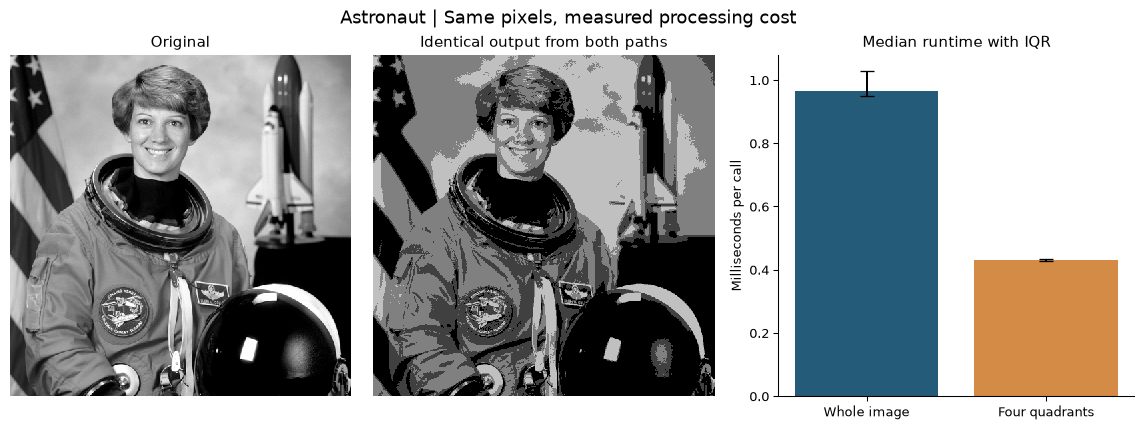

| Method | Median (ms) | 25th percentile | 75th percentile |
| --- | --- | --- | --- |
| Whole image | 0.9655 | 0.9502 | 1.0285 |
| Four quadrants | 0.4297 | 0.4259 | 0.4341 |

Quadrant / whole-image ratio: 0.445x. Outputs identical: True.


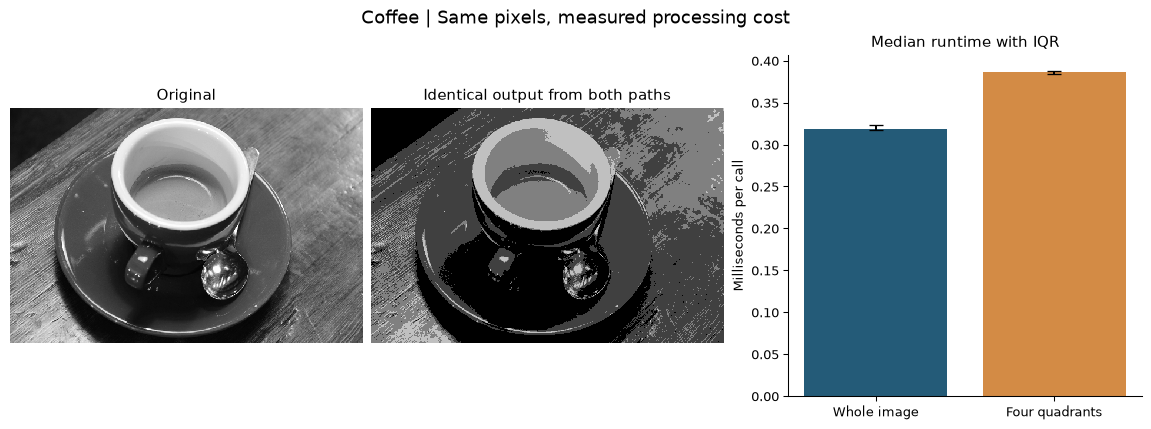

| Method | Median (ms) | 25th percentile | 75th percentile |
| --- | --- | --- | --- |
| Whole image | 0.3189 | 0.3174 | 0.3229 |
| Four quadrants | 0.3867 | 0.3844 | 0.3877 |

Quadrant / whole-image ratio: 1.213x. Outputs identical: True.


In [3]:
for name, photo in images.items():
    image = photo["gray"]
    whole = quantize(image)
    pieces = quantize_by_quadrant(image)
    assert np.array_equal(whole, pieces)
    timings = benchmark_pair({"Whole image": lambda: quantize(image), "Four quadrants": lambda: quantize_by_quadrant(image)})
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.4), layout="constrained")
    show_image(axes[0], image, "Original")
    show_image(axes[1], whole, "Identical output from both paths")
    labels = list(timings)
    medians = [timings[k]["median_ms"] for k in labels]
    lower = [timings[k]["median_ms"] - timings[k]["q25_ms"] for k in labels]
    upper = [timings[k]["q75_ms"] - timings[k]["median_ms"] for k in labels]
    axes[2].bar(labels, medians, yerr=[lower, upper], capsize=5, color=["#245b78", "#d38b45"])
    axes[2].set_ylabel("Milliseconds per call")
    axes[2].set_title("Median runtime with IQR")
    axes[2].set_ylim(bottom=0)
    fig.suptitle(name.title() + " | Same pixels, measured processing cost", fontsize=14)
    show_figure(fig)
    show_table(["Method", "Median (ms)", "25th percentile", "75th percentile"], [[k, f"{v['median_ms']:.4f}", f"{v['q25_ms']:.4f}", f"{v['q75_ms']:.4f}"] for k, v in timings.items()])
    ratio = timings["Four quadrants"]["median_ms"] / timings["Whole image"]["median_ms"]
    print(f"Quadrant / whole-image ratio: {ratio:.3f}x. Outputs identical: True.")
    RESULTS[name] = {"timings": timings, "ratio": ratio, "outputs_identical": True}

## 4. Interpretation

A ratio above one means the quadrant pipeline took longer in this run. Splitting creates extra calls and allocation work, while different array sizes can affect caching. These measurements describe this execution; they do not establish a universal speed ranking.

In [4]:
sample = np.arange(35, dtype=np.uint8).reshape(5, 7)
assert np.array_equal(quantize(sample), quantize_by_quadrant(sample))
assert set(np.unique(quantize(np.arange(256, dtype=np.uint8)))) == {0, 64, 128, 192}
print("PASS: pixel equality for both photos and odd dimensions; quantized range verified.")

PASS: pixel equality for both photos and odd dimensions; quantized range verified.
